<a href="https://colab.research.google.com/github/Blodreina912/MACHINE-LEARNING-PROJECTS/blob/main/ML_ASSIGNMENT_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving archive (1).zip to archive (1).zip
User uploaded file "archive (1).zip" with length 788976 bytes


In [6]:
import zipfile
import os

# Specify the path to the zip file
zip_file_path = 'archive (1).zip'

# Create a directory to extract the contents into, if it doesn't exist
extract_dir = 'extracted_archive'
os.makedirs(extract_dir, exist_ok=True)

# Open the zip file in read mode
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # Extract all the contents into the specified directory
    zip_ref.extractall(extract_dir)

print(f"Contents of '{zip_file_path}' extracted to '{extract_dir}/'")

# Optionally, list the extracted files
print("Extracted files:")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))

Contents of 'archive (1).zip' extracted to 'extracted_archive/'
Extracted files:
extracted_archive/kc_house_data.csv


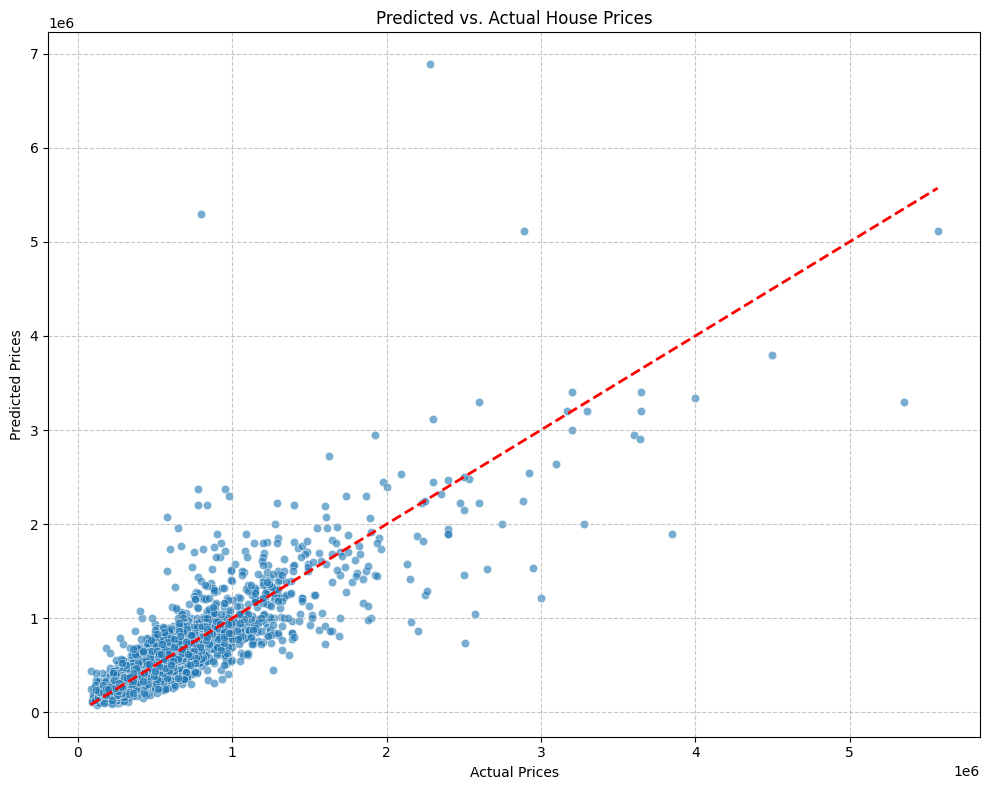

Scatter plot of predicted vs. actual prices generated successfully.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Predicted vs. Actual House Prices')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Scatter plot of predicted vs. actual prices generated successfully.")

In [20]:
import pandas as pd

# Display the first 10 predicted prices and actual prices for comparison
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(results_df.head(10))

,Actual,Predicted
735,365000.0,436500.0
2830,865000.0,710000.0
4106,1038000.0,1225000.0
16218,1490000.0,1580000.0
19964,711000.0,700000.0
1227,211000.0,260000.0
18849,790000.0,898000.0
19369,680000.0,625000.0
20164,384500.0,415000.0
7139,605000.0,565000.0


In [21]:
df = df.drop('id', axis=1)
print("'id' column dropped from the DataFrame.")
print(df.head())

'id' column dropped from the DataFrame.
        date     price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0 2014-10-13  221900.0         3       1.00         1180      5650     1.0   
1 2014-12-09  538000.0         3       2.25         2570      7242     2.0   
2 2015-02-25  180000.0         2       1.00          770     10000     1.0   
3 2014-12-09  604000.0         4       3.00         1960      5000     1.0   
4 2015-02-18  510000.0         3       2.00         1680      8080     1.0   

   waterfront  view  condition  ...  sqft_basement  yr_built  yr_renovated  \
0           0     0          3  ...              0      1955             0   
1           0     0          3  ...            400      1951          1991   
2           0     0          3  ...              0      1933             0   
3           0     0          5  ...            910      1965             0   
4           0     0          3  ...              0      1987             0   

   zipcode      lat   

In [22]:
df['price_category'] = pd.qcut(df['price'], q=4, labels=['low', 'medium', 'high', 'very high'])
print("Price column categorized into 'price_category'.")
print("Value counts for 'price_category':")
print(df['price_category'].value_counts())

Price column categorized into 'price_category'.
Value counts for 'price_category':
price_category
medium       5460
low          5404
high         5376
very high    5373
Name: count, dtype: int64


In [23]:
X = df.drop(['price', 'date', 'price_category'], axis=1)
y = df['price_category']

print("First 5 rows of X (features):")
display(X.head())
print("\nFirst 5 rows of y (target variable):")
display(y.head())

First 5 rows of X (features):


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
0,3,1.00,1180,5650,1.0,0,0,3,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,3,2.25,2570,7242,2.0,0,0,3,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,2,1.00,770,10000,1.0,0,0,3,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,4,3.00,1960,5000,1.0,0,0,5,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,3,2.00,1680,8080,1.0,0,0,3,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2



First 5 rows of y (target variable):


,price_category
0,low
1,high
2,low
3,high
4,high


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets for classification.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data split into training and testing sets for classification.
Shape of X_train: (17290, 20)
Shape of X_test: (4323, 20)
Shape of y_train: (17290,)
Shape of y_test: (4323,)


In [25]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the classifier using the training data
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier initialized and trained successfully.")

Decision Tree Classifier initialized and trained successfully.


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Make predictions on the test set
y_pred_classifier = dt_classifier.predict(X_test)

# 2. Calculate classification metrics
accuracy = accuracy_score(y_test, y_pred_classifier)
precision = precision_score(y_test, y_pred_classifier, average='weighted')
recall = recall_score(y_test, y_pred_classifier, average='weighted')
f1 = f1_score(y_test, y_pred_classifier, average='weighted')

# 3. Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classifier)

# 4. Print all calculated metrics and the confusion matrix
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)


Accuracy: 0.6900
Precision (weighted): 0.6929
Recall (weighted): 0.6900
F1-Score (weighted): 0.6913

Confusion Matrix:
[[629  24 241 173]
 [ 23 837 200   5]
 [210 196 646  19]
 [215   7  27 871]]


In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Instantiate StandardScaler and fit/transform X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Instantiate PCA with n_components=2
pca = PCA(n_components=2)

# 3. Fit and transform the scaled features to get 2D PCA-transformed data
X_pca = pca.fit_transform(X_scaled)

print("Features scaled and PCA applied successfully.")
print(f"Shape of original features X: {X.shape}")
print(f"Shape of scaled features X_scaled: {X_scaled.shape}")
print(f"Shape of PCA-transformed features X_pca: {X_pca.shape}")

Features scaled and PCA applied successfully.
Shape of original features X: (21613, 20)
Shape of scaled features X_scaled: (21613, 20)
Shape of PCA-transformed features X_pca: (21613, 2)


In [28]:
from sklearn.model_selection import train_test_split

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

print("PCA-transformed data split into training and testing sets for classification.")
print(f"Shape of X_train_pca: {X_train_pca.shape}")
print(f"Shape of X_test_pca: {X_test_pca.shape}")
print(f"Shape of y_train_pca: {y_train_pca.shape}")
print(f"Shape of y_test_pca: {y_test_pca.shape}")

PCA-transformed data split into training and testing sets for classification.
Shape of X_train_pca: (17290, 2)
Shape of X_test_pca: (4323, 2)
Shape of y_train_pca: (17290,)
Shape of y_test_pca: (4323,)


In [29]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate the Decision Tree Classifier with random_state=42
dt_classifier_pca = DecisionTreeClassifier(random_state=42)

# Train the classifier using the PCA-transformed training data
dt_classifier_pca.fit(X_train_pca, y_train_pca)

print("Decision Tree Classifier trained successfully on PCA-transformed data.")

Decision Tree Classifier trained successfully on PCA-transformed data.


In [30]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(X, y, classifier, title, x_label='Principal Component 1', y_label='Principal Component 2'):
    # Set up marker and color maps for plotting
    cmap_light = plt.cm.get_cmap('RdYlBu', 4) # For decision regions, adjust according to number of classes
    cmap_bold = plt.cm.get_cmap('viridis', 4) # For data points

    # Get min and max for meshgrid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create a meshgrid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict class for each point in the meshgrid
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Convert categorical labels to numerical for plotting contourf
    # Map 'low', 'medium', 'high', 'very high' to 0, 1, 2, 3 respectively
    label_mapping = {label: i for i, label in enumerate(classifier.classes_)}
    y_numeric = np.array([label_mapping[label] for label in y])
    Z_numeric = np.array([label_mapping[label] for label in Z.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    # Plot the decision regions
    plt.contourf(xx, yy, Z_numeric, cmap=cmap_light, alpha=0.8)

    # Plot the actual data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y_numeric, cmap=cmap_bold, edgecolor='k', s=20)

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.colorbar(scatter, ticks=range(len(classifier.classes_)), label='Price Category')
    # Add a custom legend to map numerical ticks back to original labels
    cbar = plt.gca().collections[0].colorbar
    cbar.set_ticklabels(classifier.classes_)
    plt.show()

print("Decision boundary plotting function defined.")

Decision boundary plotting function defined.


In [34]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(X, y, classifier, title, x_label='Principal Component 1', y_label='Principal Component 2'):
    # Set up marker and color maps for plotting
    cmap_light = plt.get_cmap('RdYlBu', 4) # Corrected call for discrete colormap
    cmap_bold = plt.get_cmap('viridis', 4) # Corrected call for discrete colormap

    # Get min and max for meshgrid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create a meshgrid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict class for each point in the meshgrid
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Convert categorical labels to numerical for plotting contourf
    # Map 'low', 'medium', 'high', 'very high' to 0, 1, 2, 3 respectively
    label_mapping = {label: i for i, label in enumerate(classifier.classes_)}
    y_numeric = np.array([label_mapping[label] for label in y])
    Z_numeric = np.array([label_mapping[label] for label in Z.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    # Plot the decision regions
    plt.contourf(xx, yy, Z_numeric, cmap=cmap_light, alpha=0.8)

    # Plot the actual data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y_numeric, cmap=cmap_bold, edgecolor='k', s=20)

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    # Assign the colorbar instance directly
    cbar = plt.colorbar(scatter, ticks=range(len(classifier.classes_)), label='Price Category')
    # Add a custom legend to map numerical ticks back to original labels
    cbar.set_ticklabels(classifier.classes_)
    plt.show()

print("Decision boundary plotting function defined and updated for robustness.")

Decision boundary plotting function defined and updated for robustness.


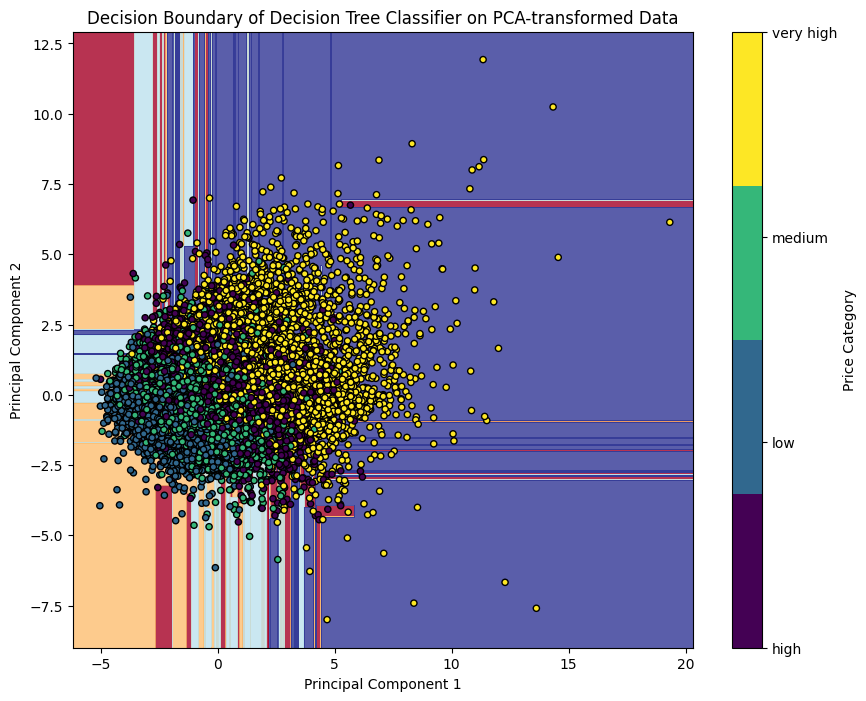

In [35]:
plot_decision_boundary(X_pca, y, dt_classifier_pca, 'Decision Boundary of Decision Tree Classifier on PCA-transformed Data')